## Лабораторная работа №4
### Компьютерное зрение

**Выполнил:** Изгородин Илья Юрьевич  
**Группа:** ФИТ-232  
**Факультет:** ФИТиКС ОмГТУ  

*Омск, 2026*

Перед началом выполнения работы устанавливаю и импотрирую библиотеки, необходимые для поставленных заданий

In [17]:
!pip install opencv-python==4.13.0.92 opencv-contrib-python==4.13.0.92 matplotlib numpy

������� ������� ��������: 1251


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Задание 1. Склейка панорамы

Загружаю два отдельных изображения с пересечением объектов на них

In [ ]:
def load_and_resize(paths, max_size=640):
    images = []
    for p in paths:
        img = cv2.imread(p)
        h, w = img.shape[:2]
        scale = max_size / max(h, w)
        if scale < 1:
            img = cv2.resize(img, (int(w*scale), int(h*scale)))
        images.append(img)
    return images

paths = ["pano_img1.jpg", "pano_img2.jpg"]
images = load_and_resize(paths)

Вывожу изображения, чтобы убедиться, что всё в порядке

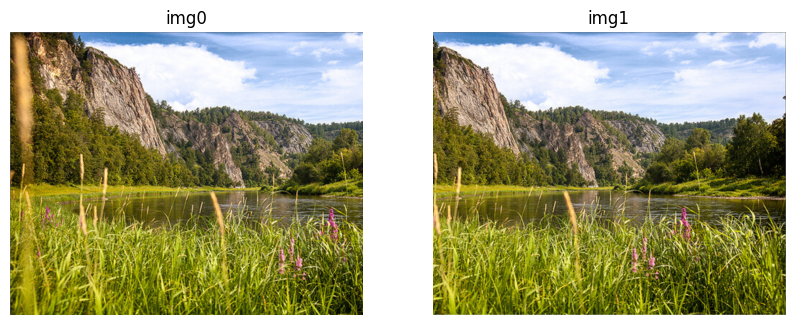

In [4]:
def show_images(imgs, titles=None):
    plt.figure(figsize=(10,5))
    for i, img in enumerate(imgs):
        plt.subplot(1, len(imgs), i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(titles[i] if titles else f"img{i}")
        plt.axis('off')
    plt.show()

show_images(images)

Определение ключевых точек и дескрипторов алгоритмом SIFT

In [5]:
def compute_sift(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(gray, None)
    return kp, des

kp1, des1 = compute_sift(images[0])
kp2, des2 = compute_sift(images[1])

Отображение ключевых точек

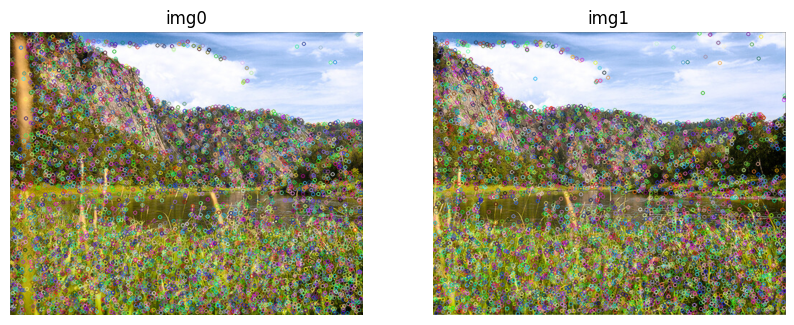

In [6]:
def draw_keypoints(img, kp):
    return cv2.drawKeypoints(img, kp, None)

show_images([
    draw_keypoints(images[0], kp1),
    draw_keypoints(images[1], kp2)
])

Сопоставление дескрипторов

In [7]:
def match_descriptors(des1, des2):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)
    return good

matches = match_descriptors(des1, des2)

Отображение сопоставления дескрипторов

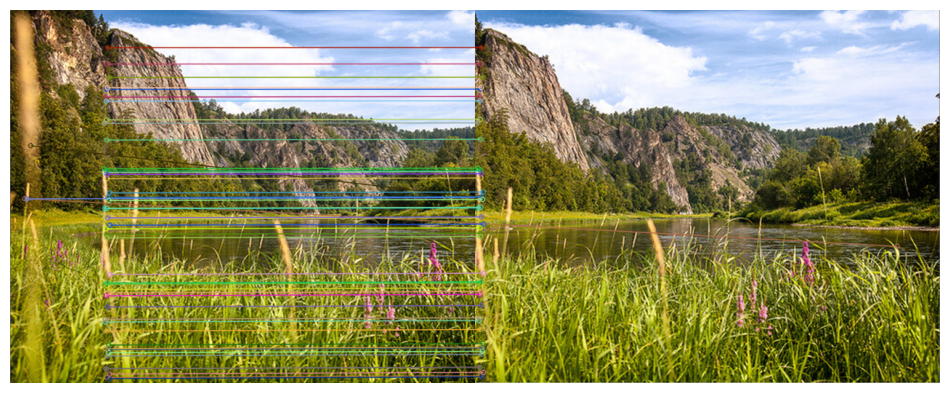

In [8]:
def draw_matches(img1, kp1, img2, kp2, matches, max_draw=50):
    img = cv2.drawMatches(
        img1, kp1, img2, kp2,
        matches[:max_draw], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plt.figure(figsize=(12,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

draw_matches(images[0], kp1, images[1], kp2, matches)

Вычисление гомографии

In [9]:
def compute_homography(kp1, kp2, matches):
    if len(matches) < 4:
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches])

    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
    return H

H = compute_homography(kp1, kp2, matches)

Объединение изображений (правое к левому)

In [10]:
def stitch_images(images):
    img1, img2 = images

    kp1, des1 = compute_sift(img1)
    kp2, des2 = compute_sift(img2)

    matches = match_descriptors(des1, des2)
    H = compute_homography(kp1, kp2, matches)

    if H is None:
        return None

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img2 = np.float32([
        [0,0], [w2,0], [w2,h2], [0,h2]
    ]).reshape(-1,1,2)

    warped_corners = cv2.perspectiveTransform(corners_img2, H)

    corners_img1 = np.float32([
        [0,0], [w1,0], [w1,h1], [0,h1]
    ]).reshape(-1,1,2)

    all_corners = np.concatenate((warped_corners, corners_img1), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel())
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel())

    shift = [-xmin, -ymin]

    H_shift = np.array([
        [1, 0, shift[0]],
        [0, 1, shift[1]],
        [0, 0, 1]
    ]) @ H

    result = cv2.warpPerspective(img2, H_shift, (xmax - xmin, ymax - ymin))
    result[shift[1]:h1+shift[1], shift[0]:w1+shift[0]] = img1

    return result

Вывод исходных изображений и результирующей панорамы

In [11]:
def show_panorama_layout(img1, img2, pano):
    plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Image 1")
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.title("Image 2")
    plt.axis('off')

    plt.subplot(2,1,2)
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.title("Panorama")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Применение функции объединения и вывод результата

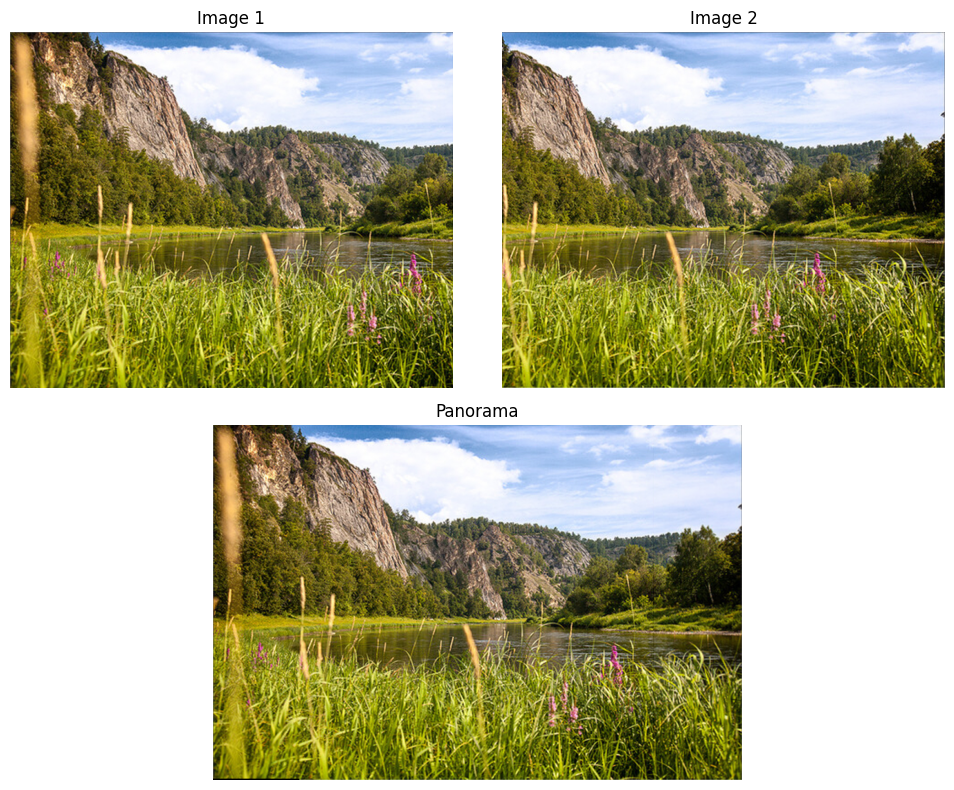

In [12]:
panorama = stitch_images(images)

if panorama is not None:
    show_panorama_layout(images[0], images[1], panorama)
else:
    print("Недостаточно совпадений")

# Задание 2. Оптический поток Лукаса-Канаде

Загрузка кадров синтетических данных (Urban sample 8 frames)

In [13]:
def load_frames_from_images(folder, max_frames=10, start_index=0):
    frames = []

    for i in range(start_index, start_index + max_frames):
        path = os.path.join(folder, f"frame{'0' + str(i) if i < 10 else i}.png")
        if not os.path.exists(path):
            break

        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        frames.append(gray)

    return frames

frames = load_frames_from_images("frames", max_frames=8, start_index=7)

Алгоритм оптического потока Лукаса-Канаде

In [14]:
def optic_flow(img1, img2, window_size=5):
    Ix = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    It = img2.astype(np.float64) - img1.astype(np.float64)

    u = np.zeros(img1.shape)
    v = np.zeros(img1.shape)

    w = window_size // 2

    for y in range(w, img1.shape[0] - w):
        for x in range(w, img1.shape[1] - w):
            Ix_win = Ix[y-w:y+w+1, x-w:x+w+1].flatten()
            Iy_win = Iy[y-w:y+w+1, x-w:x+w+1].flatten()
            It_win = It[y-w:y+w+1, x-w:x+w+1].flatten()

            A = np.vstack((Ix_win, Iy_win)).T
            b = -It_win

            ATA = A.T @ A
            if np.linalg.det(ATA) < 1e-5:
                continue

            nu = np.linalg.inv(ATA) @ A.T @ b
            u[y, x] = nu[0]
            v[y, x] = nu[1]

    return u, v

Вывод кадров оптического потока с направлениями

In [15]:
def draw_flow(img, u, v, step=10):
    h, w = img.shape
    plt.figure(figsize=(8,6))
    plt.imshow(img, cmap='gray')

    y, x = np.mgrid[0:h:step, 0:w:step]
    plt.quiver(x, y, u[::step, ::step], v[::step, ::step])

    plt.axis('off')
    plt.show()

Вывод результатов работы алгоритма (7 кадров, последний не в счёт)

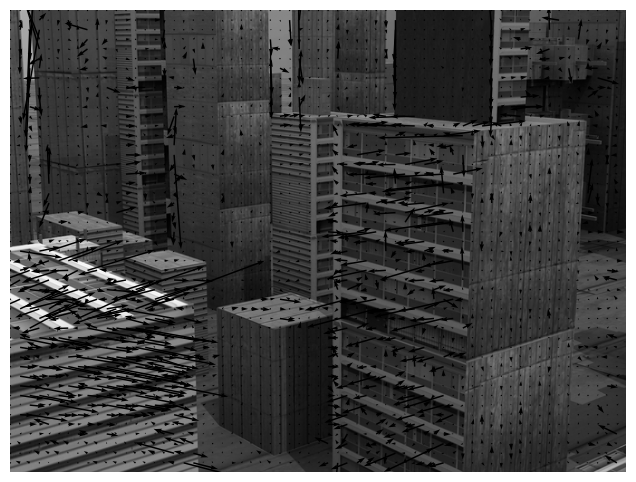

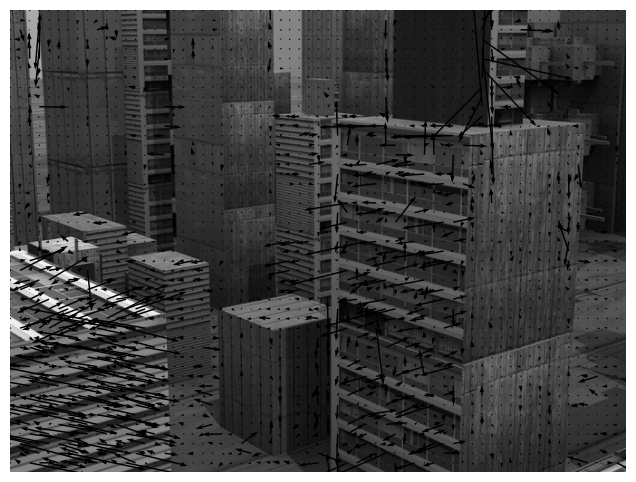

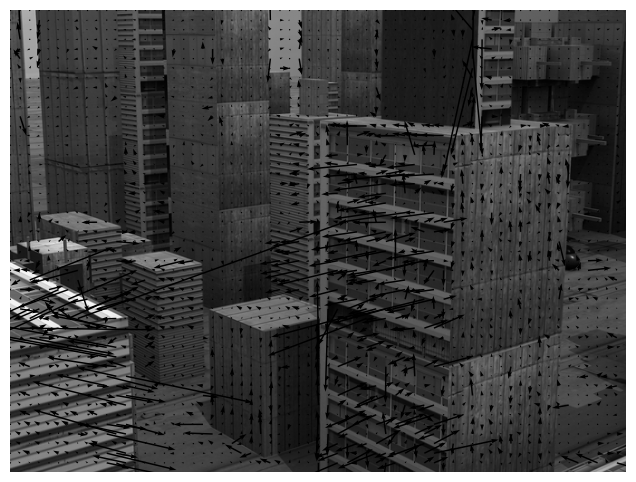

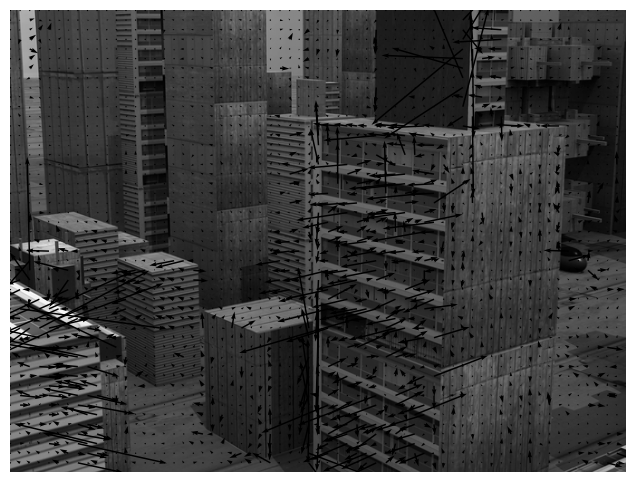

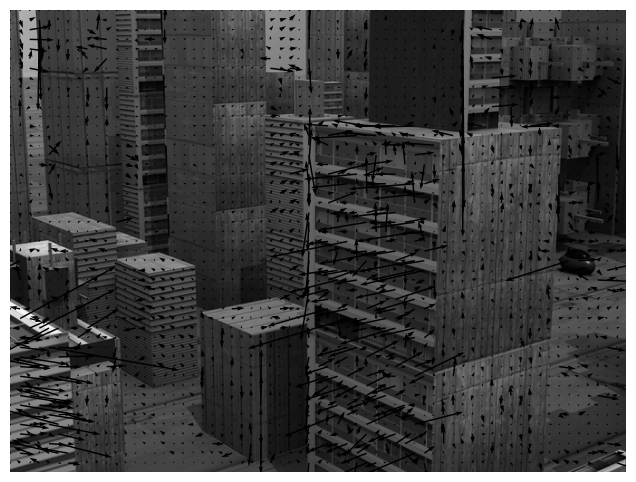

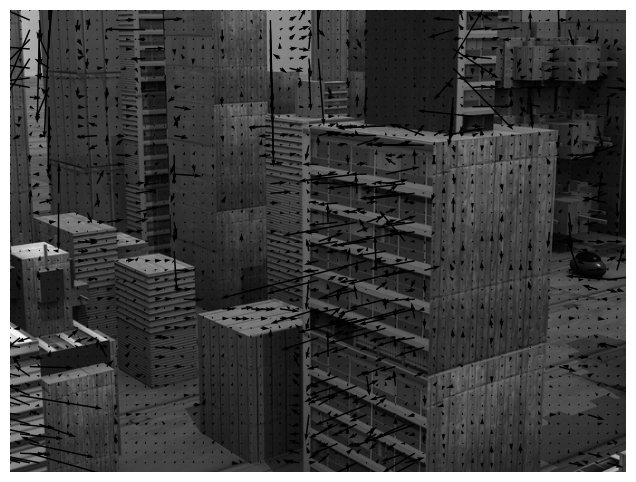

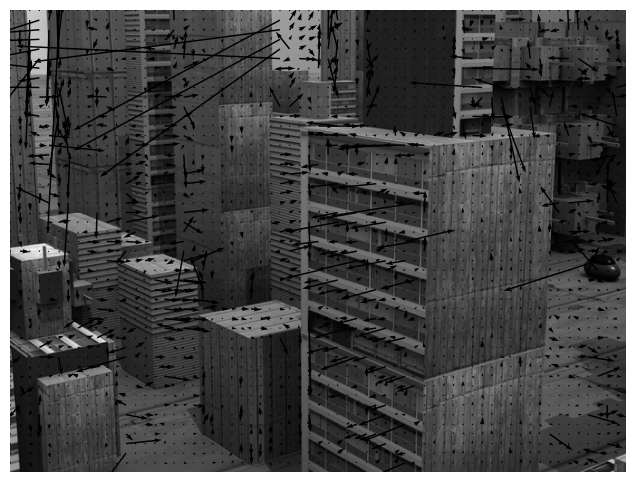

In [16]:
for i in range(len(frames) - 1):
    u, v = optic_flow(frames[i], frames[i+1], window_size=7)
    draw_flow(frames[i], u, v)